# Reconstructive and Generative Embeddings

## Reconstructive Embeddings

The core principle of reconstructive embeddings is that the quality of a
learned representation, or embedding, is measured by its ability to
reconstruct the original input data from it, meaning it somehow encodes all
the necessary information, in a lower-dimensional latent space $z$, needed to
describe the data. The goal is not to generate new data but simply to compress
and describe existing data.

The most common model for this task is the Autoencoder (AE). An Autoencoder consists of two primary components: an **Encoder** and a **Decoder**. The Encoder $e(\cdot)$ is a network that maps the high-dimensional input data $X$ to the low-dimensional latent embedding $z$, as described by $z = e(X)$. The Decoder $d(\cdot)$ is a network that attempts to reverse this process, mapping the embedding $z$ back to a reconstruction $\hat{X}$ of the original input, such as $\hat{X} = d(z) = d(e(X)) \approx X$.

This architecture forces the network to learn a compressed representation because the dimensionality of $z$ is significantly smaller than that of $X$, creating an "information bottleneck." To learn, the model is trained to minimize a **reconstruction loss**, which is simply the difference between the original input $X$ and its reconstruction $\hat{X}$. For image data, this loss function is often the Mean Squared Error (MSE), $L(X, \hat{X}) = ||X - \hat{X}||^2$, which penalizes differences in pixel values.

The resulting latent space of a standard Autoencoder is optimized purely for
this compression-reconstruction task. It is *not* structured for generation.
The space between learned data points in $z$ is often un-mapped and undefined.
If one were to sample two embeddings $z_1$ and $z_2$ from two different inputs
and interpolate between them, the decoded results would likely be non-sensical
or non-plausible, as the model has no incentive to make the whole of the
latent space meaningful.

A key variant is the **Denoising Autoencoder**, which is fed a corrupted input $X'$ but is trained to reconstruct the original *clean* data $X$. This forces the embedding $z$ to capture more robust and essential features, learning to discard noise. The most prominent application of reconstructive models is **anomaly detection**. A model trained only on "normal" data will learn to reconstruct it very well (low error). When presented with an anomalous sample, it will fail to reconstruct it accurately, resulting in a high reconstruction error that flags the data as an outlier. This approach is also widely used for dimensionality reduction and non-linear feature extraction.

## Generative Embeddings

The primary principle of generative embeddings is to learn to produce new
datapoints that appear as if they could be a member of a dataset.
Mathematically, we say that they are learning the underlying probability
distribution $P(X)$ of the training data. For example, if we are working with
a dataset of images of dogs, we start by thinking about all possible images,
including static, pictures of people, abstract art, etc. A small portion of
that space is likely to appear in a dataset of image sof dogs.

Unlike reconstructive models, which aim to compress and decompress known data,
generative models are designed to **synthesize new, novel data samples**
$\hat{X}$ that are plausible and appear to be drawn from the same distribution
as the original data. This requires learning a latent space $z$ that is not
just a compressed code but a structured, continuous representation from which
meaningful samples can be drawn.

### The Variational Autoencoder (VAE)

The **Variational Autoencoder (VAE)** is a probabilistic generative model that directly modifies the Autoencoder architecture to achieve this. It effectively builds a bridge between reconstruction and generation by imposing a specific structure on its latent space.

The VAE's encoder is **probabilistic**. Instead of mapping an input $X$ to a single, deterministic latent vector $z$, the encoder outputs the parameters—a mean vector $(\mu)$ and a variance vector $(\sigma^2)$—that define a Gaussian probability distribution. The latent vector $z$ is then *sampled* from this distribution, $z \sim \mathcal{N}(\mu, \sigma^2)$. This sampling step is a crucial distinction, as it introduces a controlled stochasticity into the encoding process.

The decoder $d(\cdot)$ functions as a "generator." It takes one of these sampled latent vectors $z$ and attempts to reconstruct the original input $\hat{X} = d(z)$.

The key to the VAE's function lies in its unique loss function, derived from the Evidence Lower Bound (ELBO), which has two components:

1.  **Reconstruction Loss:** This is the same as in a standard Autoencoder, such as Mean Squared Error $L(X, \hat{X})$. This term encourages the model to be a good autoencoder, ensuring that the sampled embedding $z$ contains enough information to faithfully reconstruct the original input $X$.
2.  **Kullback-Leibler (KL) Divergence:** This term $D_{KL}(\mathcal{N}(\mu, \sigma^2) || \mathcal{N}(0, I))$ acts as a powerful regularizer. It measures the difference between the distribution $\mathcal{N}(\mu, \sigma^2)$ output by the encoder and a standard normal distribution (mean=0, variance=1), which is set as a *prior*.

This KL divergence term forces the latent space to be **organized**. It penalizes the encoder for creating distributions that are far from the origin or have very small variances. This prevents the model from "cheating" by assigning each data point to a separate, non-overlapping region of the latent space. By forcing all encoded distributions toward the central $\mathcal{N}(0, I)$ prior, the VAE ensures the latent space is **continuous** and densely populated. 
 
Because the latent space is continuous and centered, the VAE is generative. We can now discard the encoder, sample a random vector $z$ directly from the prior distribution $\mathcal{N}(0, I)$, and pass it to the decoder. The decoder, trained on this structured space, will generate a new, plausible data sample $\hat{X}$ that is not a copy of any single item in the training set. 
 
### Generative Adversarial Networks (GANs) 
 
A different generative philosophy is used by **Generative Adversarial Networks (GANs)**. GANs do not use reconstruction. Instead, they model the generation process as a zero-sum game between two competing networks: 
 
1.  A **Generator $G(\cdot)$** takes a random noise vector $z$ (sampled from $\mathcal{N}(0, I)$) and attempts to create a fake data sample $\hat{X} = G(z)$. 
2.  A **Discriminator $D(\cdot)$** acts as a classifier, trained to distinguish real data $X$ from the generator's fake data $\hat{X}$. 
 
The Generator is trained to produce fakes that *fool* the Discriminator, while the Discriminator is trained to *not be fooled*. This adversarial process forces the Generator to produce increasingly realistic samples. The latent space $z$ of a GAN learns a complex mapping from simple noise to the data manifold, often resulting in sharper, more realistic images than VAEs, though their training is known to be less stable.

## VAE Demo

This notebook demonstrates the training of a variational autoencoder (VAE) on the MNIST dataset.  The decoder portion of the VAE is then used to generate arbitrary, new MNIST-like digits.

Note that we didn't reinvent this wheel - the code comes from [this excellent tutorial](https://medium.com/@rekalantar/variational-auto-encoder-vae-pytorch-tutorial-dce2d2fe0f5f).

In [1]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.optim as optim
import os

In [2]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

data = MNIST('./mnist_data', transform=transform, download=True)
loader = DataLoader(dataset=data, batch_size=100, shuffle=True, num_workers=20)

100%|██████████████████████████████████████| 9.91M/9.91M [00:00<00:00, 91.2MB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 5.91MB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 24.2MB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 19.6MB/s]


## The network

The cells above just set up our dataset and dataloader.

Below is the definition of our VAE.  Note that in the encoder, it decreases from 784 dimensions, to 400, to 200, and ultimately to 2, which are interpreted as a mean and variance of a distribution. To decode, we create a random point in 2-dimensional space, where each dimension is a number pulled from a normal distribution centered at that mean and with that variance.  That 200-dimensional point is then enlarged to a 400-dimensional point, and finally back to a 784-dimensional output.

Our loss function then has two components:
- The distance between the output image to the input image, and
- The distance between the mean and standard deviation and mean 0 and standard deviation 1.

The first component ensures the correct reproduction of the image.  The second ensures that the latent values going into the decoder are in a predictable region.

In [3]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200):
        super(VAE, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, latent_dim),
            nn.LeakyReLU(0.2)
            )
        
        # latent mean and variance 
        self.mean_layer = nn.Linear(latent_dim, 2)
        self.logvar_layer = nn.Linear(latent_dim, 2)
        
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, latent_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
            )
     
    def encode(self, x):
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to('cuda')      
        z = mean + var*epsilon
        return z

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        x_hat = self.decode(z)
        return x_hat, mean, logvar

In [4]:
model = VAE().to('cuda')
optimizer = optim.Adam(model.parameters(), lr=1e-3)

The loss function is defined below.  `reproduction_loss` is the distance between the output and input images, and `KLD` is the [Kullback-Liebler divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence), which measures the distance between the mean and variance and mean 0 and variance 1.

In [5]:
def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD

In [6]:
def train(model, optimizer, epochs, x_dim=784):
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(loader):
            x = x.view(100, x_dim).to('cuda')

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)
            
            overall_loss += loss.item()
            
            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*100))
    return overall_loss

filename='mnist_autoencoder.pt'
if os.path.isfile(filename):
    model.load_state_dict(torch.load(filename))
    model=model.to('cuda')
else:
    train(model, optimizer, epochs=50)
    torch.save(model.state_dict(), filename)

	Epoch 1 	Average Loss:  177.85066267672684
	Epoch 2 	Average Loss:  158.71659849749582
	Epoch 3 	Average Loss:  154.30402622534953
	Epoch 4 	Average Loss:  151.4754175253026
	Epoch 5 	Average Loss:  149.27180359192403
	Epoch 6 	Average Loss:  147.33723212189588
	Epoch 7 	Average Loss:  145.74482335467968
	Epoch 8 	Average Loss:  144.45540893350898
	Epoch 9 	Average Loss:  143.3631599214837
	Epoch 10 	Average Loss:  142.5755713787302
	Epoch 11 	Average Loss:  141.84929661414859
	Epoch 12 	Average Loss:  141.14139366391902
	Epoch 13 	Average Loss:  140.5873025354758
	Epoch 14 	Average Loss:  140.03623306096097
	Epoch 15 	Average Loss:  139.44493076025145
	Epoch 16 	Average Loss:  139.10646280584828
	Epoch 17 	Average Loss:  138.6446035547527
	Epoch 18 	Average Loss:  138.48991717967445
	Epoch 19 	Average Loss:  138.0170099253965
	Epoch 20 	Average Loss:  137.65742626056448
	Epoch 21 	Average Loss:  137.29986153680613
	Epoch 22 	Average Loss:  137.1244306102619
	Epoch 23 	Average Loss:  

OK, it's trained.  Now let's throw away the encoder, and play around with the decoder alone.  We know that the latent representations of MNIST numbers will have a small mean and a variance close to 1 (log_var close to 0).  So let's plug in some different values for MEAN and LOG_VAR which are close to that, and see what comes out of the decoder!

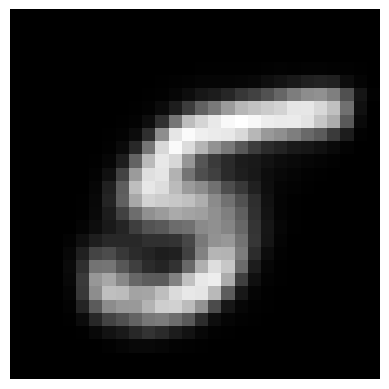

In [9]:
MEAN=.1
LOG_VAR=.1

z_sample = torch.tensor([[MEAN,LOG_VAR]],dtype=torch.float32).to('cuda')
x_decoded = model.decode(z_sample)
digit = x_decoded.detach().cpu().reshape(28,28)
plt.imshow(digit, cmap='gray')
plt.axis('off')
plt.show()

That's pretty wild.  Let's try doing the same thing, but for many values of MEAN and LOG_VAR, and see how they relate.

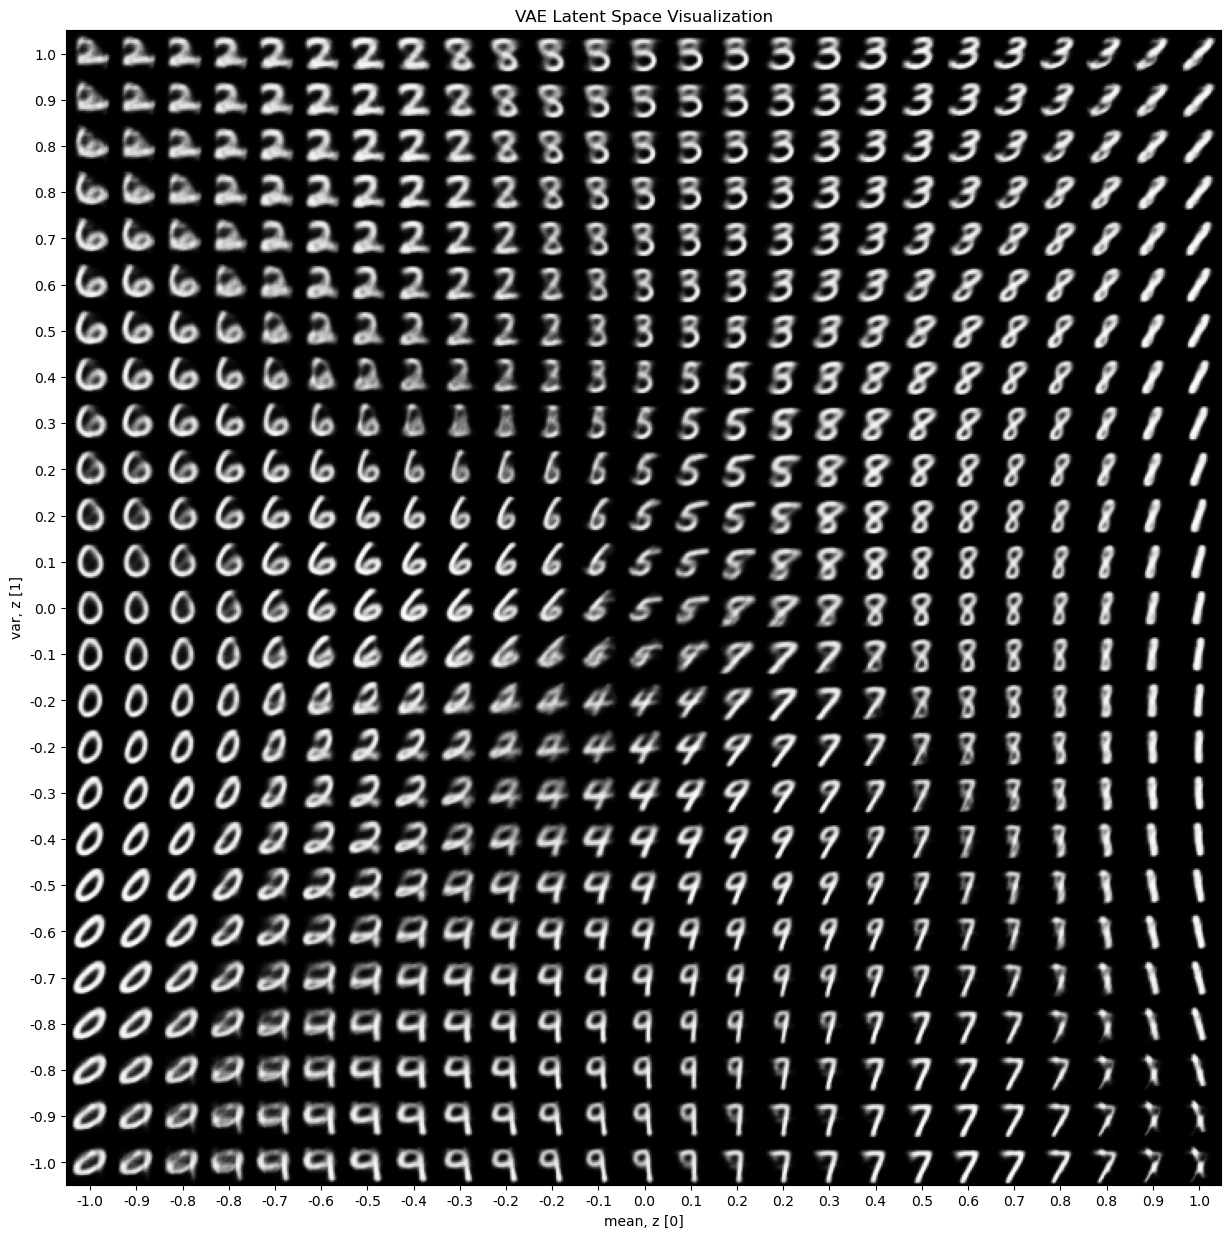

In [10]:
def plot_latent_space(model, scale=1.0, n=25, digit_size=28, figsize=15):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid 
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to('cuda')
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("mean, z [0]")
    plt.ylabel("var, z [1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(model)